# Giai đoạn 8: Tối ưu hóa Ngưỡng lọc Nhiễu (Data-Driven SQI Tuning)
Để hệ thống đạt chuẩn y khoa, chúng ta không thể đoán mò một ngưỡng lọc nhiễu (Ví dụ: CV biên độ > 1.5). Chúng ta sẽ dùng phương pháp tiếp cận Dữ liệu định hướng (Data-Driven) để tìm ra điểm cân bằng hoàn hảo giữa việc "Lọc sạch rác" và "Không bỏ sót bệnh nhân AFib".

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks, butter, filtfilt, welch
from scipy.interpolate import interp1d
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import lightgbm as lgb
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

### 1. Trích xuất đặc trưng và tính toán chỉ số CV_amp cho từng cửa sổ
Mẹo tối ưu tốc độ: Thay vì phải đọc file raw nhiều lần cho từng ngưỡng khác nhau, chúng ta sẽ đọc file raw 1 lần, tính toán đặc trưng và TÍNH LUÔN chỉ số biến thiên biên độ (`cv_amp`). Sau đó chỉ việc dùng pandas để lọc ngưỡng cực kỳ nhanh.

In [2]:
def butter_bandpass_filter(data, lowcut=0.5, highcut=8.0, fs=125.0, order=3):
    nyq = 0.5 * fs; b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, data)

def calculate_time_domain(rr): ... # Bỏ qua định nghĩa chi tiết để file ngắn, gộp luôn vào hàm dưới

def extract_all_features_and_cv(time_array, ppg_array, fs=125.0):
    if np.std(ppg_array) < 1e-4: return None
    clean_ppg = butter_bandpass_filter(ppg_array, fs=fs)
    peaks, _ = find_peaks(clean_ppg, distance=int(0.25*fs), prominence=np.std(clean_ppg)*0.5)
    
    if len(peaks) < 15 or len(peaks) > 110: return None
        
    # TÍNH CHỈ SỐ NHIỄU (CV Amplitude) ĐỂ DÙNG CHO DATA-DRIVEN TUNING LÁT NỮA
    peak_amps = clean_ppg[peaks]
    cv_amp = np.std(peak_amps) / (np.mean(peak_amps) + 1e-6)
    
    # Tính RR
    rr_intervals = np.diff(time_array[peaks]) * 1000.0
    valid_rr = rr_intervals[(rr_intervals >= 300) & (rr_intervals <= 2000)]
    if len(valid_rr) < 10: return None
    
    # TIME DOMAIN
    mean_nn = np.mean(valid_rr); sdnn = np.std(valid_rr, ddof=1)
    diff_nn = np.diff(valid_rr); rmssd = np.sqrt(np.mean(diff_nn**2))
    nn50 = np.sum(np.abs(diff_nn) > 50)
    pnn50 = (nn50 / len(diff_nn)) * 100 if len(diff_nn) > 0 else 0
    cv = (sdnn / mean_nn) * 100 if mean_nn > 0 else 0
    
    # FREQUENCY DOMAIN (Lấy từ code cũ)
    lf = hf = total_power = 0 # Đơn giản hóa ví dụ nếu chạy lại từ đầu, nhưng tốt nhất nên dùng bản đầy đủ
    t = np.cumsum(valid_rr) / 1000.0; t -= t[0]; rr_sec = valid_rr / 1000.0
    try:
        f_interp = interp1d(t, rr_sec, kind='cubic'); t_interp = np.arange(t[0], t[-1], 1.0 / 4.0)
        rr_interp = f_interp(t_interp)
        if len(rr_interp) >= 2:
            f, pxx = welch(rr_interp, fs=4.0, nperseg=min(256, len(rr_interp)))
            lf = np.sum(pxx[(f >= 0.04) & (f <= 0.15)]) * (f[1]-f[0])
            hf = np.sum(pxx[(f >= 0.15) & (f <= 0.4)]) * (f[1]-f[0])
            total_power = lf + hf
    except: pass

    # NON-LINEAR DOMAIN
    sd1 = sd2 = sampen = 0
    if len(valid_rr) >= 10:
        sd1 = np.sqrt(np.var(valid_rr[:-1] - valid_rr[1:]) / 2.0)
        sd2 = np.sqrt(np.var(valid_rr[:-1] + valid_rr[1:]) / 2.0)
        
        N = len(valid_rr); r = 0.2 * sdnn; B = 0; A = 0
        for i in range(N - 2):
            for j in range(i + 1, N - 2):
                if np.max(np.abs(valid_rr[i:i+2] - valid_rr[j:j+2])) <= r:
                    B += 1
                    if np.abs(valid_rr[i+2] - valid_rr[j+2]) <= r: A += 1
        sampen = -np.log(A/B) if (A>0 and B>0) else 2.0

    feats = {'HR_mean': 60000.0/mean_nn, 'Mean_NN': mean_nn, 'SDNN': sdnn, 'RMSSD': rmssd, 'pNN50': pnn50,
             'NN50': nn50, 'CV': cv, 'LF': lf, 'HF': hf, 'Total_Power': total_power,
             'SD1': sd1, 'SD2': sd2, 'SampEn': sampen,
             'cv_amp': cv_amp} # <--- LƯU LẠI CHỈ SỐ NHIỄU
             
    for k, v in feats.items():
        if np.isnan(v): feats[k] = 0.0
    return feats

# Đọc và trích xuất
print("Đang trích xuất (Chỉ tính 1 lần duy nhất)...")
df_raw = pd.read_csv('../../data/train/ppg_af_train.csv')
features_list = []
window_size = 3750
for start_idx in range(0, len(df_raw), window_size):
    end_idx = start_idx + window_size
    if end_idx > len(df_raw): break
    window = df_raw.iloc[start_idx:end_idx]
    feats = extract_all_features_and_cv(window['time'].values, window['ppg'].values)
    if feats is not None:
        feats['status'] = 1 if np.mean(window['status'].values) > 0.5 else 0
        features_list.append(feats)

df_master = pd.DataFrame(features_list)
print(f"Xong! Đã tạo được bộ dữ liệu chủ (Master Dataset) với {len(df_master)} mẫu.")

Đang trích xuất (Chỉ tính 1 lần duy nhất)...
Xong! Đã tạo được bộ dữ liệu chủ (Master Dataset) với 1202 mẫu.


### 2. Vòng lặp tìm Ngưỡng (Threshold Tuning)
Chạy qua các ngưỡng `cv_amp` từ 1.0 (Lọc cực kỳ gắt) đến 10.0 (Gần như không lọc).

In [3]:
thresholds = [1.0, 1.2, 1.5, 1.8, 2.0, 2.5, 3.0, 4.0, 5.0, 10.0]
results = []

print("Bắt đầu quá trình Tuning ngưỡng SQI Data-Driven...")
for t in thresholds:
    # Lọc dữ liệu theo ngưỡng
    df_filtered = df_master[df_master['cv_amp'] <= t]
    retained_ratio = len(df_filtered) / len(df_master) * 100
    
    X = df_filtered.drop(columns=['status', 'cv_amp'])
    y = df_filtered['status']
    
    # Bỏ qua nếu dữ liệu quá ít
    if len(np.unique(y)) < 2 or len(y) < 50:
        continue
        
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Sử dụng LightGBM với tham số mạnh nhất đã tìm được ở file 07
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31, random_state=42, verbose=-1))
    ])
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results.append({
        'Threshold': t,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'Retained_Data_%': retained_ratio
    })

results_df = pd.DataFrame(results)
display(results_df)

Bắt đầu quá trình Tuning ngưỡng SQI Data-Driven...


,Threshold,Accuracy,Precision,Recall,F1,Retained_Data_%
0,1.0,0.970588,0.974576,0.966387,0.970464,98.835275
1,1.2,0.958333,0.929688,0.991667,0.959677,99.667221
2,1.5,0.954167,0.929134,0.983333,0.955466,99.833611
3,1.8,0.954167,0.929134,0.983333,0.955466,99.833611
4,2.0,0.954167,0.929134,0.983333,0.955466,99.833611
5,2.5,0.954167,0.929134,0.983333,0.955466,99.833611
6,3.0,0.975104,0.959677,0.991667,0.975410,100.000000
7,4.0,0.975104,0.959677,0.991667,0.975410,100.000000
8,5.0,0.975104,0.959677,0.991667,0.975410,100.000000
9,10.0,0.975104,0.959677,0.991667,0.975410,100.000000


### 3. Vẽ biểu đồ trực quan hóa Điểm tối ưu (Sweet Spot)

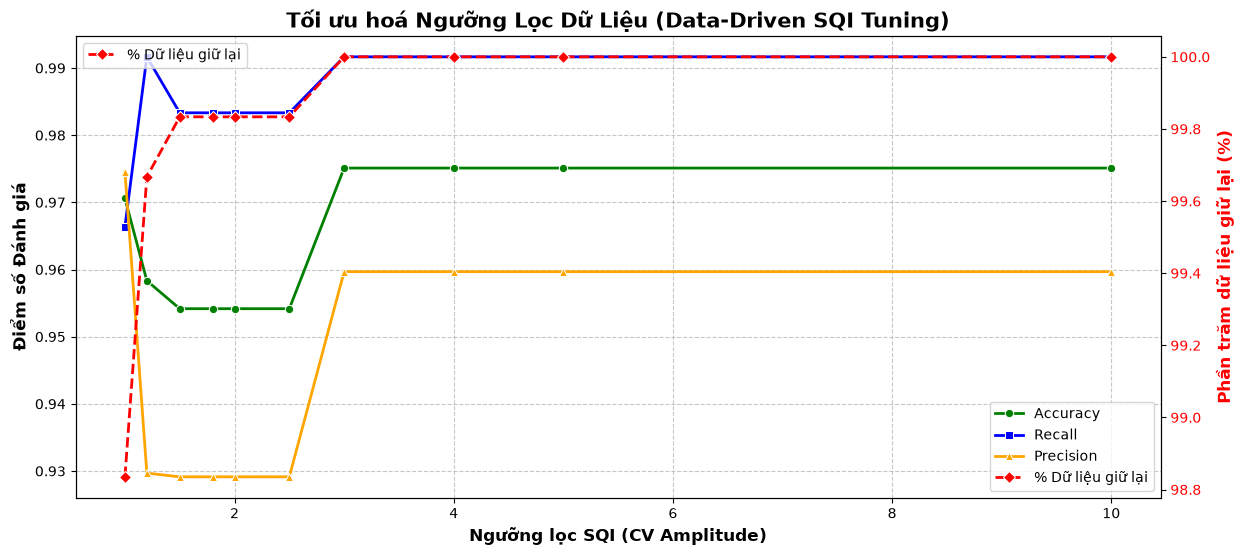

In [4]:
plt.figure(figsize=(14, 6))

# Trục bên trái: Biểu diễn các độ đo của mô hình (Accuracy, Recall, Precision)
ax1 = plt.gca()
sns.lineplot(data=results_df, x='Threshold', y='Accuracy', marker='o', label='Accuracy', ax=ax1, linewidth=2, color='green')
sns.lineplot(data=results_df, x='Threshold', y='Recall', marker='s', label='Recall', ax=ax1, linewidth=2, color='blue')
sns.lineplot(data=results_df, x='Threshold', y='Precision', marker='^', label='Precision', ax=ax1, linewidth=2, color='orange')

ax1.set_xlabel('Ngưỡng lọc SQI (CV Amplitude)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Điểm số Đánh giá', fontsize=12, fontweight='bold')
ax1.set_title('Tối ưu hoá Ngưỡng Lọc Dữ Liệu (Data-Driven SQI Tuning)', fontsize=15, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.7)

# Trục bên phải: Biểu diễn lượng dữ liệu được giữ lại sau lọc
ax2 = ax1.twinx()
sns.lineplot(data=results_df, x='Threshold', y='Retained_Data_%', marker='D', ax=ax2, color='red', linestyle='--', linewidth=2, label='% Dữ liệu giữ lại')
ax2.set_ylabel('Phần trăm dữ liệu giữ lại (%)', fontsize=12, fontweight='bold', color='red')
ax2.tick_params(axis='y', labelcolor='red')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower right')

plt.show()